# Advanced: Thermal Validation Against HALO-(AC)³

In this notebook, we'll compare pyRadtran's thermal broadband simulations against measurements from multiple aircraft during the HALO-(AC)³ campaign. We validate downwelling thermal irradiance against observations and compute statistical error metrics.

## Setup

In [1]:
import pyradtran
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# ── Simulation parameters ─────────────────────────────────────────────────────
# Paths come from ~/.pyradtran/config.yaml (master config)
# radiosonde_base is overridden in the saved YAML to use local sounding data
cfg = load_config()

cfg.simulation_defaults.rte_solver           = "disort"
cfg.simulation_defaults.mol_abs_param        = "reptran medium"
cfg.simulation_defaults.source               = "solar"
cfg.simulation_defaults.wavelength_nm        = [290, 4500]
cfg.simulation_defaults.integrate_wavelength = True
cfg.simulation_defaults.h2o_source           = "radiosonde"
cfg.simulation_defaults.ozone_du             = None   # use radiosonde
cfg.simulation_defaults.h2o_mm               = None   # use radiosonde
cfg.simulation_defaults.surface_temperature_k = 253.15
cfg.simulation_defaults.output_altitudes_km  = [0.0]
cfg.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg.execution.max_workers                    = 32
cfg.execution.cleanup_temp_files             = False
cfg.execution.timeout_seconds               = 3600

# Override radiosonde_base to use local sounding data bundled in the notebook
cfg.paths.radiosonde_base = str(Path("~/pyRadtran/book/notebooks/radiosonde/").expanduser())

config_path = Path("config/halo-ac3_bbr_all_aircraft.yaml")
cfg.to_yaml(config_path)
print(f"Config saved to {config_path}")

2026-04-18 17:57:09,849 - pyradtran.config - INFO - Configuration written to config/halo-ac3_bbr_all_aircraft.yaml


Config saved to config/halo-ac3_bbr_all_aircraft.yaml


## Data Preparation

In [2]:
# Load CSV and convert to xarray Dataset
df = pd.read_csv('data/HALO-AC3_HALO_P5_P6_aircraft_broadband_radiation_clear_sky_with_ocean_100s.csv', parse_dates=['time'])
df = df.set_index('time')

ds = xr.Dataset.from_dataframe(df).drop_duplicates('time').sortby('time')
ds_to_sim = ds.rename({'Lat': 'latitude', 'Lon': 'longitude', 'Alt': 'altitude'})

# Use uncorrected solar flux where available
ds_to_sim['F_down_solar'].loc[{'time': ds_to_sim.F_down_solar_uncorr.notnull()}] = ds_to_sim.F_down_solar_uncorr.loc[{'time': ds_to_sim.F_down_solar_uncorr.notnull()}]

# Compute albedo from upwelling/downwelling solar flux
albedo = (ds_to_sim['F_up_solar'] / ds_to_sim['F_down_solar'])
albedo = albedo.where(albedo < 1)  # Remove unphysical values > 1
ds_to_sim['albedo'] = ('time', albedo.astype(float).values)
ds_to_sim['albedo'] = ds_to_sim['albedo'].fillna(0.5)  # Default albedo for NaN values

# Convert altitude from meters to km
ds_to_sim['altitude'] = ds_to_sim['altitude'] / 1e3
ds_to_sim = ds_to_sim.assign_coords(altitude=ds_to_sim['altitude'])

# Define output altitude grid (0–12 km in 1 km steps)
ds_to_sim['altitude'] = ('altitude', np.arange(0, 13, 1))

## Running Simulations

In [3]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
ds_sim = ds_to_sim.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    output_path='data/Simulated_HALO-AC3_HALO_P5_P6_aircraft_broadband_radiation_clear_sky_with_ocean_100s.nc',
    show_progress=False,
)

print("\nSimulation complete!")
ds_sim

Running batch spectral simulation...


Running simulations:   0%|          | 0/215 [00:00<?, ?sim/s]

Running simulations:   0%|          | 1/215 [00:03<11:26,  3.21s/sim]

Running simulations:   0%|          | 1/215 [00:03<11:26,  3.21s/sim, Success=1, Total=215]

Running simulations:   1%|          | 2/215 [00:03<11:22,  3.21s/sim, Success=2, Total=215]

...

Running simulations: 100%|██████████| 215/215 [04:40<00:00,  1.50sim/s, Success=213, Total=215]

Running simulations: 100%|██████████| 215/215 [04:40<00:00,  1.50sim/s, Success=214, Total=215]

Running simulations: 100%|██████████| 215/215 [04:40<00:00,  1.31s/sim, Success=214, Total=215]


Simulation complete!


<xarray.Dataset> Size: 203kB
Dimensions:   (time: 215, altitude: 13)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2022-03-12T12:03:20 ... 2022-04-12T12...
  * altitude  (altitude) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
Data variables:
    zout      (altitude, time) float64 22kB 0.0 0.0 0.0 0.0 ... 12.0 12.0 12.0
    lambda    (altitude, time) float64 22kB 290.0 290.0 290.0 ... 290.0 290.0
    sza       (altitude, time) float64 22kB 81.68 84.29 84.3 ... 80.21 79.67
    edir      (altitude, time) float64 22kB 9.137e+04 5.127e+04 ... 2.064e+05
    eglo      (altitude, time) float64 22kB 1.229e+05 7.456e+04 ... 2.18e+05
    edn       (altitude, time) float64 22kB 3.155e+04 2.329e+04 ... 1.156e+04
    eup       (altitude, time) float64 22kB 1.045e+05 6.338e+04 ... 1.604e+05
    enet      (altitude, time) float64 22kB 1.844e+04 1.118e+04 ... 5.754e+04
    albedo    (altitude, time) float64 22kB 0.85 0.85 0.85 ... 0.7345 0.736
Attributes: (12/22)
    point_id:                      20220312_120320_77.52_-9.58_0
    time:                          2022-03-12T12:03:20
    latitude:                      77.51616
    longitude:                     -9.577096
    generated_by:                  pyradtran
    pyradtran_version:             unified_system
    ...                            ...
    config_integrate_wavelength:   1
    config_output_altitudes_km:    [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8...
    config_libradtran_bin:         /opt/libRadtran-2.0.6/bin/uvspec
    config_libradtran_data:        /opt/libRadtran-2.0.6/data
    config_max_workers:            32
    config_timeout_seconds:        3600

## Simulation Results

Spectral radiative transfer calculations completed using DISORT solver with multi-level output altitude grid.

## Solar Irradiance: Time Series and Scatter Comparison

In [4]:
ds_sim_alt = ds_sim.sel(altitude=ds.Alt / 1e3, method='nearest')

In [5]:
ds_sim_alt

<xarray.Dataset> Size: 19kB
Dimensions:   (time: 215)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2022-03-12T12:03:20 ... 2022-04-12T12...
    altitude  (time) float64 2kB 12.0 12.0 12.0 12.0 12.0 ... 3.0 3.0 3.0 5.0
Data variables:
    zout      (time) float64 2kB 12.0 12.0 12.0 12.0 12.0 ... 3.0 3.0 3.0 5.0
    lambda    (time) float64 2kB 290.0 290.0 290.0 290.0 ... 290.0 290.0 290.0
    sza       (time) float64 2kB 81.68 84.29 84.3 86.69 ... 80.53 80.21 79.67
    edir      (time) float64 2kB 1.646e+05 1.065e+05 ... 1.462e+05 1.715e+05
    eglo      (time) float64 2kB 1.755e+05 1.156e+05 ... 1.755e+05 1.971e+05
    edn       (time) float64 2kB 1.086e+04 9.142e+03 ... 2.921e+04 2.553e+04
    eup       (time) float64 2kB 1.18e+05 7.498e+04 ... 1.405e+05 1.525e+05
    enet      (time) float64 2kB 5.745e+04 4.063e+04 ... 3.5e+04 4.458e+04
    albedo    (time) float64 2kB 0.6726 0.6486 0.6485 ... 0.8002 0.8005 0.7738
Attributes: (12/22)
    point_id:                      20220312_120320_77.52_-9.58_0
    time:                          2022-03-12T12:03:20
    latitude:                      77.51616
    longitude:                     -9.577096
    generated_by:                  pyradtran
    pyradtran_version:             unified_system
    ...                            ...
    config_integrate_wavelength:   1
    config_output_altitudes_km:    [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8...
    config_libradtran_bin:         /opt/libRadtran-2.0.6/bin/uvspec
    config_libradtran_data:        /opt/libRadtran-2.0.6/data
    config_max_workers:            32
    config_timeout_seconds:        3600

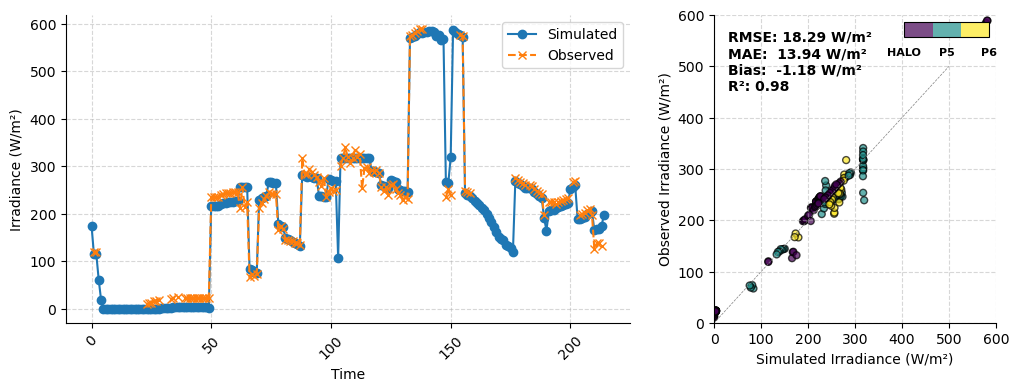

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors

fig, (ax, ax_scatter) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})

# --- Categorical coloring by airplane type ---
airplane_cat = ds_to_sim['airplane'].to_series().astype('category')
airplane_codes = airplane_cat.cat.codes
airplane_types = airplane_cat.cat.categories
n_colors = len(airplane_types)

# --- Time series: simulated vs observed downwelling solar irradiance ---
ax.plot(ds_sim_alt.eglo / 1e3, marker='o', linestyle='-', label='Simulated')
ax.plot(ds_to_sim.F_down_solar, marker='x', linestyle='--', label='Observed')
ax.set_xlabel('Time')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# --- Scatter plot: simulated vs observed, colored by aircraft ---
cmap = plt.get_cmap('viridis', n_colors)
scatter = ax_scatter.scatter(
    ds_sim_alt.eglo / 1e3, ds_to_sim.F_down_solar,
    c=airplane_codes, cmap=cmap, s=25, alpha=0.7, edgecolor='k',
)
ax_scatter.set_xlabel('Simulated Irradiance (W/m²)')
ax_scatter.set_ylabel('Observed Irradiance (W/m²)')
ax_scatter.set_xlim(0, 600)
ax_scatter.set_ylim(0, 600)
ax_scatter.plot(np.arange(0, 600, 100), np.arange(0, 600, 100), color='gray', linestyle='--', linewidth=0.5)

# --- Error metrics ---
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = ds_sim_alt.eglo.values / 1000
Y = ds_to_sim.F_down_solar.values
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask]
Y = Y[nan_mask]

rmse = np.sqrt(mean_squared_error(X, Y))
bias = np.mean(X - Y)
r2 = r2_score(X, Y)
mae = mean_absolute_error(X, Y)

stats_text = f'RMSE: {rmse:.2f} W/m²\nMAE:  {mae:.2f} W/m²\nBias:  {bias:.2f} W/m²\nR²: {r2:.2f}'
ax_scatter.text(0.05, 0.95, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top', fontweight='bold')

# --- Inset colorbar for aircraft categories ---
cax = inset_axes(ax_scatter, width="30%", height="5%", loc='upper right')
norm = mcolors.BoundaryNorm(np.arange(n_colors + 1) - 0.5, n_colors)
cb = fig.colorbar(scatter, cax=cax, orientation='horizontal', ticks=np.arange(n_colors), norm=norm)
cb.set_ticklabels(airplane_types, fontweight='bold')
cb.ax.tick_params(labelsize=8)
cax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False)
cax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# --- Formatting ---
for a in [ax, ax_scatter]:
    a.grid(True, linestyle='--', alpha=0.5)
    a.spines[['top', 'right']].set_visible(False)

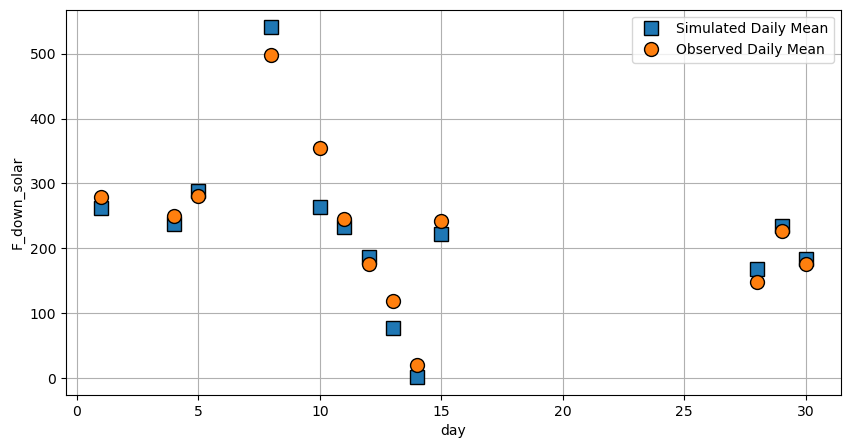

In [7]:
# Daily mean comparison: simulated vs observed
plt.figure(figsize=(10, 5))
(ds_sim_alt.groupby('time.day').mean()['eglo'] / 1000).plot(marker='s', ls='', ms=10, markeredgecolor='k', label='Simulated Daily Mean')
ds_to_sim['F_down_solar'].groupby('time.day').mean().plot(marker='o', ls='', ms=10, markeredgecolor='k', label='Observed Daily Mean')
plt.legend()
plt.grid()

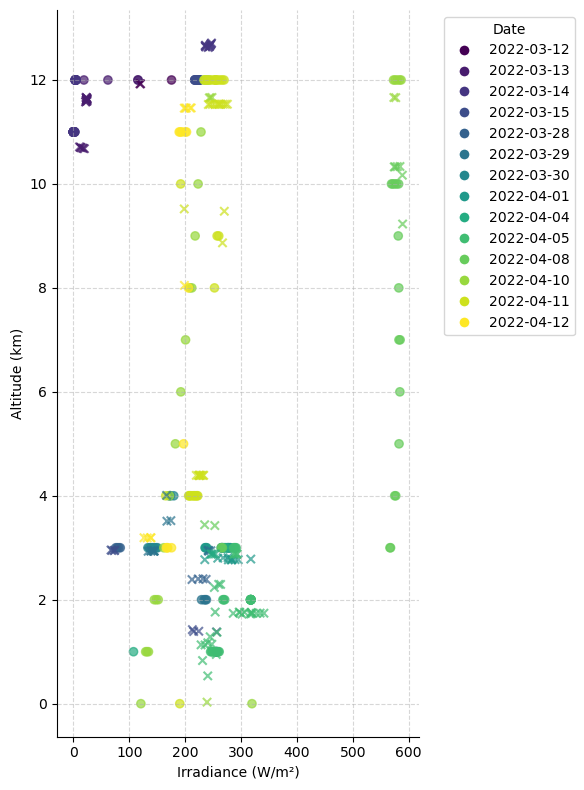

In [8]:
alt = ds_sim_alt.eglo.altitude.values

fig, ax = plt.subplots(1, figsize=(6, 8))

# Convert altitude to km for plotting
ds_to_sim['z'] = ds['Alt'] / 1e3

# Create categorical data for coloring by day
day_cat = ds_to_sim.time.to_series().dt.date.astype('category')
day_codes = day_cat.cat.codes
day_types = day_cat.cat.categories
n_colors = len(day_types)
cmap = plt.get_cmap('viridis', n_colors)

# Scatter plot: simulated irradiance vs altitude
scatter_sim = ax.scatter(ds_sim_alt.eglo.values / 1e3, alt, c=day_codes, cmap=cmap, marker='o', label='Simulated', alpha=0.7)
# Scatter plot: observed irradiance vs altitude
scatter_obs = ax.scatter(ds_to_sim.F_down_solar.values, ds_to_sim.z.values, c=day_codes, cmap=cmap, marker='x', label='Observed', alpha=0.7)

# Date legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=8) for i in range(n_colors)]
labels = [d.strftime('%Y-%m-%d') for d in day_types]
ax.legend(handles, labels, title="Date", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

ax.set_ylabel('Altitude (km)')
ax.set_xlabel('Irradiance (W/m²)')
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

## Comparing pyRadtran with Published Results

Finally, we compare our pyRadtran simulations against the aircraft observations and the published simulation results from the dataset (Becker et al., 2023). This three-way comparison validates both the measurement pipeline and our simulation approach:

Text(0.05, 0.95, 'RMSE: 18.29 W/m²\nMAE:  13.94 W/m²\nBias:  -1.18 W/m²\nR²: 0.98')

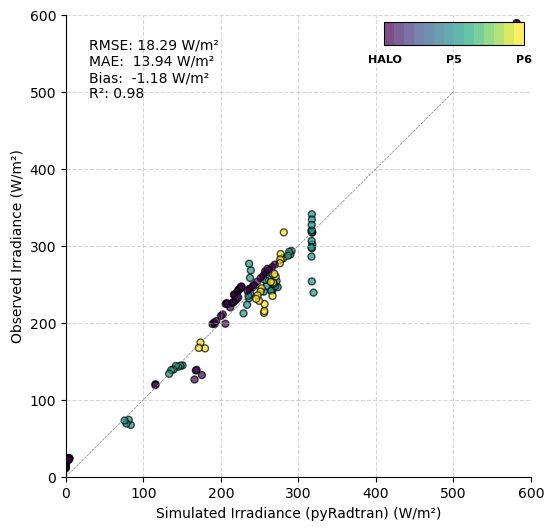

In [9]:
X = ds_sim_alt['eglo']
Y = ds_to_sim['F_down_solar']

fig, ax_scatter = plt.subplots(1, 1, figsize=(6, 6))

# --- Scatter: pyRadtran simulated vs observed irradiance ---
cmap = plt.get_cmap('viridis', n_colors)
scatter = ax_scatter.scatter(X / 1e3, Y, c=airplane_codes, cmap=cmap, s=25, alpha=0.7, edgecolor='k')
ax_scatter.set_xlabel('Simulated Irradiance (pyRadtran) (W/m²)')
ax_scatter.set_ylabel('Observed Irradiance (W/m²)')

n_colors = len(airplane_types)

# 1:1 reference line and axis limits
ax_scatter.set_xlim(0, 600)
ax_scatter.set_ylim(0, 600)
ax_scatter.plot(np.arange(0, 600, 100), np.arange(0, 600, 100), color='gray', linestyle='--', linewidth=0.5)

# Inset colorbar for aircraft categories
cax = inset_axes(ax_scatter, width="30%", height="5%", loc='upper right')
norm = mcolors.BoundaryNorm(np.arange(n_colors + 1) - 0.5, n_colors)
cb = fig.colorbar(scatter, cax=cax, orientation='horizontal', ticks=np.arange(n_colors), norm=norm)
cb.set_ticklabels(airplane_types, fontweight='bold')
cb.ax.tick_params(labelsize=8)
cax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False)
cax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
for a in [ax_scatter]:
    a.grid(True, linestyle='--', alpha=0.5)
    a.spines[['top', 'right']].set_visible(False)

# --- Error metrics ---
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask].values / 1000
Y = Y[nan_mask].values

rmse = np.sqrt(mean_squared_error(X, Y))
bias = np.mean(X - Y)
r2 = r2_score(X, Y)
mae = mean_absolute_error(X, Y)

stats_text = f'RMSE: {rmse:.2f} W/m²\nMAE:  {mae:.2f} W/m²\nBias:  {bias:.2f} W/m²\nR²: {r2:.2f}'
ax_scatter.text(0.05, 0.95, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top')

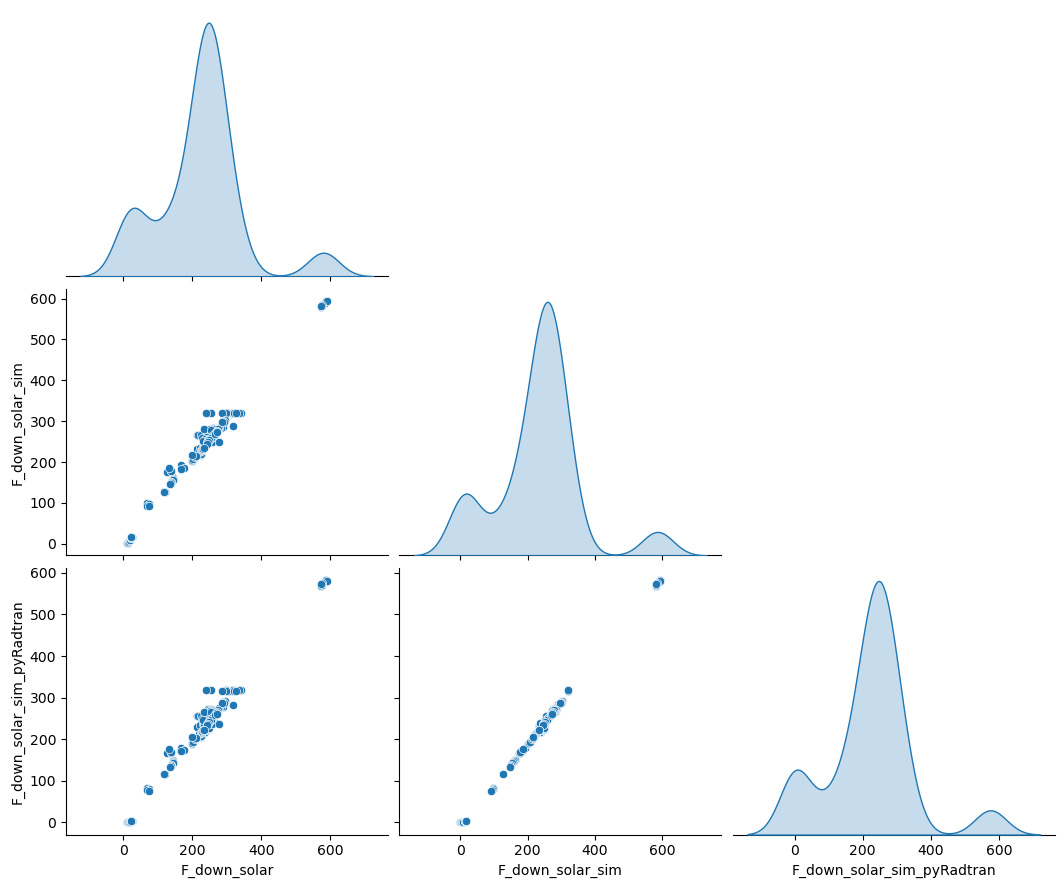

In [10]:
df_to_compare = ds[['F_down_solar', 'F_down_solar_sim']]
df_to_compare['F_down_solar_sim_pyRadtran'] = ('time', ds_sim_alt.eglo.values / 1000)  # Convert to W/m²

df_to_compare = df_to_compare.dropna('time', how='any').to_dataframe()
df_to_compare

### make this cool pandas scatter comparison plot where you can compare multiple columns 
import seaborn as sns
import matplotlib.pyplot as plt
#sns.set(style="whitegrid")
g = sns.pairplot(df_to_compare, kind='scatter', diag_kind='kde', markers=["o", "x"], height=3, aspect=1.2, corner=True)
